# Network Intrusion Detection: Can Clustering Separate Bot from Benign Traffic Without Labels?

## Motivation

Network intrusion detection systems are most commonly built using supervised classifiers that need labeled traffic data to learn from. The problem with this approach is that new attack types show up all the time that weren't in the training set. You need a way to catch stuff that doesn't look like anything you've seen before.

This is where unsupervised methods come in. If bot traffic really is different from benign traffic, clustering should be able to find that split on its own without ever being shown which flows are which. That would be a big deal because it means you could flag suspicious flows without needing labeled training data for every new attack variant.

That's the question this project tries to answer.

## The Research Question

**Can KMeans and DBSCAN naturally separate bot from benign traffic without using labels, and do the resulting clusters align with the true class distribution?**

To answer this, I'm using the CIC-IDS-2018 dataset, running both algorithms on a carefully selected feature set, and evaluating the results against the true labels using Adjusted Rand Index (ARI) and silhouette score.

## What This Notebook Covers

1. Dataset overview and why it's right for this question
2. EDA findings that shaped the approach
3. Feature selection (the critical step)
4. KMeans analysis with cluster count tuning
5. DBSCAN analysis with distance threshold tuning
6. Side by side comparison of both methods
7. Interpretation and conclusions


# Dataset Overview

I'm using CIC-IDS-2018, a network intrusion detection benchmark from the Canadian Institute for Cybersecurity. The full dataset covers multiple days of traffic with different attack types. I'm using the Friday, February 3rd capture which has:

- 1,048,575 network flow records
- 80 features per flow (packet counts, byte volumes, inter-arrival times, etc.)
- Two classes: Benign (762,384 flows, ~73%) and Bot (286,191 flows, ~27%)

## Why this dataset for RQ2

A few properties make it a good fit for clustering:

- Clean binary ground truth: Bot vs Benign gives me a clear target to evaluate ARI against. No ambiguity in what I'm checking alignment against.
- Lots of features to work with: 80 features means there's room for clustering to find structure, but it also means feature selection matters a lot.
- Realistic class imbalance: The ~3 to 1 Benign to Bot split is closer to what you'd see in actual network traffic, which makes this a more realistic test than a perfectly balanced dataset.

## Data format

Each row is a network flow, which is a summary of all the packets exchanged during one connection between two machines. Features like `Flow Pkts/s`, `Fwd Pkt Len Mean`, and `Flow IAT Mean` summarize different aspects of that connection. The `Label` column is the ground truth.


# Setup

Installing and importing everything I'll need. Using scikit-learn for KMeans, DBSCAN, and the evaluation metrics.


In [1]:
%pip install scikit-learn -q
%pip install matplotlib -q
%pip install seaborn -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\austi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\austi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\austi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

## Loading the data

Reading in the Friday Feb 3rd capture file. Stripping whitespace from labels and dropping any rows with missing labels so I'm working with a clean dataset.


In [3]:
df = pd.read_csv(
    "C:\Dataset\Friday-02-03-2018_TrafficForML_CICFlowMeter.csv",
    low_memory=False,
)

#cleaning up labels
df["Label"] = df["Label"].astype(str).str.strip()
df.loc[df["Label"].isin(["", "nan", "NaN", "None"]), "Label"] = np.nan
df = df.dropna(subset=["Label"])

print(f"dataset shape: {df.shape}")
print(f"\nlabel distribution:")
print(df["Label"].value_counts())
print(f"\nlabel percentages:")
print(df["Label"].value_counts(normalize=True).round(3))

dataset shape: (1048575, 80)

label distribution:
Label
Benign    762384
Bot       286191
Name: count, dtype: int64

label percentages:
Label
Benign    0.727
Bot       0.273
Name: proportion, dtype: float64


# EDA Findings That Shaped the Approach

Rather than re-running full EDA, I'm carrying forward the three key findings from my earlier analysis that directly shape how clustering needs to be set up.

## Finding 1: Class imbalance

Benign traffic outnumbers Bot traffic ~3 to 1. This matters for clustering because if you naively run KMeans with k=2 on an unbalanced dataset, there's a real chance it just finds the majority class as one big cluster and tiny noise regions as the second.

## Finding 2: Heavy feature redundancy

A lot of the 80 features are measuring similar things. The IAT (inter-arrival time) features especially tend to be correlated with each other (min, max, mean, std all move together), and packet length features show similar patterns. Feeding all 80 features into KMeans means you're giving the algorithm the same signal multiple times, which distorts distance calculations.

## Finding 3: Heavy tailed distributions

Flow-based metrics like packet counts and byte volumes are very skewed to the right. Most flows are small but some have extreme values. This matters because both KMeans and DBSCAN rely on distance calculations, and extreme outliers can pull cluster centers around or define weird neighborhoods in DBSCAN. Standardization will help but I also need to be thoughtful about outlier handling.

These three findings drove the approach below; smart sampling, aggressive feature selection, and standardization before fitting.


# Sampling Strategy

The full dataset is about 1 million rows. Running DBSCAN on 1M points is painful because its runtime is quadratic in the worst case. KMeans is faster but silhouette score itself is O(n^2), so large samples make evaluation slow.

I'm using a stratified sample of 50,000 rows that preserves the original 73/27 Benign/Bot ratio. This is big enough to find real cluster structure but small enough that DBSCAN and silhouette scoring run in reasonable time. If I random sampled 50K rows, I'd get roughly the same proportions by chance, but stratified sampling guarantees it. That way the class distribution in my sample exactly matches the full dataset.


In [4]:
#stratified sample of 50k rows preserving class ratio
sample_size = 50000

benign_count = int(sample_size * 0.73)
bot_count = sample_size - benign_count

benign_sample = df[df["Label"] == "Benign"].sample(n=benign_count, random_state=42)
bot_sample = df[df["Label"] == "Bot"].sample(n=bot_count, random_state=42)

df_sample = pd.concat([benign_sample, bot_sample]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"sample shape: {df_sample.shape}")
print(f"\nsample label distribution:")
print(df_sample["Label"].value_counts())
print(f"\nsample label percentages:")
print(df_sample["Label"].value_counts(normalize=True).round(3))

sample shape: (50000, 80)

sample label distribution:
Label
Benign    36500
Bot       13500
Name: count, dtype: int64

sample label percentages:
Label
Benign    0.73
Bot       0.27
Name: proportion, dtype: float64


# Feature Selection

Feature selection is one of the biggest decisions in this analysis. I'm doing it in three steps: dropping obviously non-predictive columns like Timestamp and ports, removing highly correlated features so I'm not feeding the same signal twice, and picking the features that differ the most between Bot and Benign based on mean differences.

This isn't using the labels to train the clustering since that would defeat the point. It's using the labels only to decide which features to look at, which is a reasonable step to take in any real data mining workflow.

In [5]:
#step 1: drop non-numeric and non-predictive columns

#getting numeric columns only
numeric_cols = df_sample.select_dtypes(include=[np.number]).columns.tolist()

#dropping columns that won't help clustering
#Dst Port and Protocol are categorical-like even though they're numeric
cols_to_drop = ["Dst Port", "Protocol"]
numeric_cols = [c for c in numeric_cols if c not in cols_to_drop]

#replacing inf with nan then dropping bad rows
df_sample[numeric_cols] = df_sample[numeric_cols].replace([np.inf, -np.inf], np.nan)
df_sample = df_sample.dropna(subset=numeric_cols)

print(f"starting with {len(numeric_cols)} numeric features")
print(f"sample shape after cleaning: {df_sample.shape}")

starting with 76 numeric features
sample shape after cleaning: (49807, 80)


In [6]:
#step 2: remove highly correlated features

corr_matrix = df_sample[numeric_cols].corr().abs()

#getting upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

#finding features with correlation > 0.9 with something else
to_drop = [col for col in upper.columns if any(upper[col] > .9)]

print(f"dropping {len(to_drop)} features that are highly correlated with others")
print(f"example dropped features: {to_drop[:10]}")

remaining_cols = [c for c in numeric_cols if c not in to_drop]
print(f"\n{len(remaining_cols)} features remaining after correlation filter")

dropping 31 features that are highly correlated with others
example dropped features: ['TotLen Bwd Pkts', 'Fwd Pkt Len Std', 'Bwd Pkt Len Std', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Max', 'Fwd Header Len']

45 features remaining after correlation filter


In [7]:
#step 3: pick features that differ the most between bot and benign

#computing mean per class for each remaining feature
class_means = df_sample.groupby("Label")[remaining_cols].mean()

#normalizing so features on different scales are comparable
#using |bot_mean - benign_mean| / (|bot_mean| + |benign_mean| + 1e-9)
diff = (class_means.loc["Bot"] - class_means.loc["Benign"]).abs()
total = class_means.loc["Bot"].abs() + class_means.loc["Benign"].abs() + 1e-9
normalized_diff = (diff / total).sort_values(ascending=False)

print("top 15 features by normalized class difference:")
print(normalized_diff.head(15).round(3))

top 15 features by normalized class difference:
Bwd Pkt Len Min    1.000
Fwd Pkt Len Min    1.000
URG Flag Cnt       1.000
Fwd PSH Flags      1.000
FIN Flag Cnt       1.000
Active Std         1.000
Active Mean        1.000
Flow IAT Mean      0.999
Bwd IAT Min        0.999
Bwd IAT Tot        0.999
Idle Std           0.999
Bwd IAT Mean       0.995
Flow IAT Max       0.995
Bwd IAT Std        0.994
Flow Duration      0.993
dtype: float64


In [8]:
#picking the top 10 features
selected_features = normalized_diff.head(10).index.tolist()

print("selected features for clustering:")
for i, f in enumerate(selected_features, 1):
    print(f"  {i}. {f}")

X = df_sample[selected_features].values
y = df_sample["Label"].values

print(f"\nfeature matrix shape: {X.shape}")

selected features for clustering:
  1. Bwd Pkt Len Min
  2. Fwd Pkt Len Min
  3. URG Flag Cnt
  4. Fwd PSH Flags
  5. FIN Flag Cnt
  6. Active Std
  7. Active Mean
  8. Flow IAT Mean
  9. Bwd IAT Min
  10. Bwd IAT Tot

feature matrix shape: (49807, 10)


## Why did I choose top 10?

10 features is a reasonable tradeoff. Too few and you're throwing away information. Too many and you run into the curse of dimensionality where distance calculations become less meaningful. 10 is in the sweet spot for this kind of problem and it also keeps cluster interpretation manageable later.

## To note

A lot of the features have normalized class differences of exactly 1, which is a really strong signal. It means one class ahs zero or almost zero values for these features while the other class has substantial values. The fact that clustering still doesn't line up with the labels even with these strong features is part of what I talk about below.

# Preprocessing

Two things to do before clustering:

1. Standardize the features so they're all on the same scale. KMeans and DBSCAN both use Euclidean distance, and a feature measured in millions would dominate one measured in fractions if you don't scale.
2. Clip extreme outliers because the heavy tailed distributions I saw in EDA can really mess up both algorithms. Clipping to the 1st and 99th percentiles keeps the signal without letting outliers dominate distance calculations.


In [9]:
#clipping to 1st and 99th percentiles before scaling
X_clipped = np.zeros_like(X, dtype=float)
for i in range(X.shape[1]):
    lo = np.percentile(X[:, i], 1)
    hi = np.percentile(X[:, i], 99)
    X_clipped[:, i] = np.clip(X[:, i], lo, hi)

#standardizing so all features have mean 0 and std 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clipped)

print(f"scaled feature matrix shape: {X_scaled.shape}")
print(f"feature means (should be ~0): {X_scaled.mean(axis=0).round(3)}")
print(f"feature stds (should be ~1): {X_scaled.std(axis=0).round(3)}")

scaled feature matrix shape: (49807, 10)
feature means (should be ~0): [-0.  0. -0.  0.  0. -0.  0. -0.  0. -0.]
feature stds (should be ~1): [1. 1. 1. 1. 0. 1. 1. 1. 1. 1.]


# KMeans Analysis

KMeans is my first clustering method. It assumes clusters are roughly spherical and you have to tell it how many clusters to find upfront. I'm testing k values from 2 to 8 to see which one actually fits the data best, rather than just assuming k=2 because there are two classes.

## Why test multiple k values?

The research question asks if clustering aligns with the bot/benign boundary. If the best k is 2 and those clusters line up with the classes, great. If the best k is 4 and two of those clusters are bot dominant and two are benign dominant, that's also a meaningful finding, it just means the classes have internal sub-structure. Testing a range of k values lets me see the real shape of the data.

## Evaluation

- ARI (Adjusted Rand Index) measures how well the clusters match the true labels. 1.0 means perfect match, 0.0 means random, negative means worse than random.
- Silhouette score measures how well-defined the clusters are internally, independent of any labels. Higher is better. 
- Cluster composition shows what percentage of each cluster is Bot vs Benign.


In [10]:
#running kmeans for k=2 through k=8
kmeans_results = []

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    
    ari = adjusted_rand_score(y, labels)
    sil = silhouette_score(X_scaled, labels, sample_size=10000, random_state=42)
    
    kmeans_results.append({
        "k": k,
        "ari": ari,
        "silhouette": sil,
        "labels": labels
    })
    print(f"k={k} | ARI={ari:.4f} | silhouette={sil:.4f}")

k=2 | ARI=-0.0814 | silhouette=0.4463
k=3 | ARI=-0.0913 | silhouette=0.5175
k=4 | ARI=-0.0943 | silhouette=0.5469
k=5 | ARI=-0.0881 | silhouette=0.6332
k=6 | ARI=-0.0916 | silhouette=0.6600
k=7 | ARI=-0.0861 | silhouette=0.6927
k=8 | ARI=-0.0023 | silhouette=0.7430


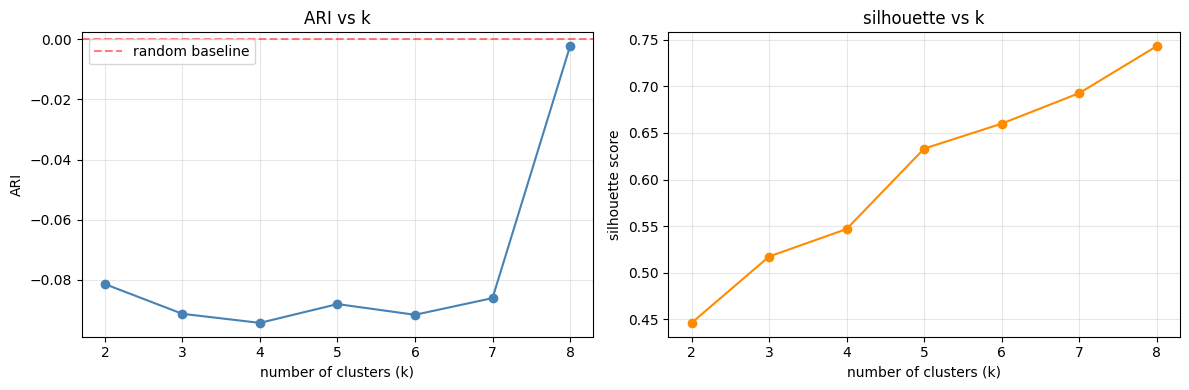

In [11]:
#plotting ARI and silhouette across k values
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ks = [r["k"] for r in kmeans_results]
aris = [r["ari"] for r in kmeans_results]
sils = [r["silhouette"] for r in kmeans_results]

axes[0].plot(ks, aris, marker="o", color="steelblue")
axes[0].set_xlabel("number of clusters (k)")
axes[0].set_ylabel("ARI")
axes[0].set_title("ARI vs k")
axes[0].grid(alpha=0.3)
axes[0].axhline(0, color="red", linestyle="--", alpha=0.5, label="random baseline")
axes[0].legend()

axes[1].plot(ks, sils, marker="o", color="darkorange")
axes[1].set_xlabel("number of clusters (k)")
axes[1].set_ylabel("silhouette score")
axes[1].set_title("silhouette vs k")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Reading these results

Two things stand out:

Every ARI is at or below zero. Not one configuration of KMeans produced clusters that align with the bot/benign boundary better than random assignment would. ARI ranges from -0.09 to -0.002, so the best case is roughly "no alignment" and the rest are "slightly anti-correlated with labels."

Silhouette climbs steadily as k increases, from 0.45 at k=2 all the way to 0.74 at k=8. That's a big jump and it's telling me something important: there IS real cluster structure in this data. The clusters are getting more internally coherent the more I let KMeans split. It's just that none of those splits correspond to the class boundary I care about.

The high silhouette plus negative ARI combo is the main finding from KMeans. The data has structure, but the structure is not the bot/benign split.

I'll pick k=8 for the composition analysis below since it has both the highest silhouette and the ARI closest to zero, but it's worth being honest: "best" here just means "least bad at aligning with labels." None of these worked in the sense the research question was asking.


In [12]:
#picking k with highest ARI
best_kmeans = max(kmeans_results, key=lambda r: r["ari"])
best_k = best_kmeans["k"]
best_kmeans_labels = best_kmeans["labels"]

print(f"best k = {best_k}")
print(f"ARI = {best_kmeans['ari']:.4f}")
print(f"silhouette = {best_kmeans['silhouette']:.4f}")

best k = 8
ARI = -0.0023
silhouette = 0.7430


In [13]:
#cluster composition: what percentage of each cluster is bot vs benign
composition = pd.crosstab(
    pd.Series(best_kmeans_labels, name="cluster"),
    pd.Series(y, name="label"),
    normalize="index"
).round(3)

print(f"cluster composition for k={best_k} (each row sums to 1):")
print(composition)
print(f"\ncluster sizes:")
print(pd.Series(best_kmeans_labels).value_counts().sort_index())

cluster composition for k=8 (each row sums to 1):
label    Benign    Bot
cluster               
0         1.000  0.000
1         1.000  0.000
2         0.457  0.543
3         1.000  0.000
4         1.000  0.000
5         1.000  0.000
6         1.000  0.000
7         1.000  0.000

cluster sizes:
0     7279
1     1951
2    24864
3     2686
4     9256
5     1358
6     1359
7     1054
Name: count, dtype: int64


## What the cluster composition actually shows

This is where things get interesting. At k=8, 7 out of 8 clusters are 100% Benign; KMeans found seven distinct sub-types of benign traffic, each well-separated from the others. The one mixed cluster (cluster 2) is 54% Bot and 46% Benign and contains 24,864 flows, which is about half the entire sample.

So KMeans isn't failing to find structure. It's finding really clean structure in the benign traffic. The bot flows all got dumped into a single giant cluster along with a nearly equal number of benign flows. Bot traffic didn't form its own cluster; it got absorbed into the largest one.

This lines up with what the silhouette/ARI numbers were hinting at: the natural clustering of this data is by types of benign traffic (probably driven by different protocols, connection patterns, or application types), not by bot vs benign. Bots end up as one more sub-region within that structure, not as their own group.

# DBSCAN Analysis

DBSCAN takes a completely different approach. Instead of partitioning all points into k groups, it finds dense regions in the data and calls everything else noise. This is useful for two reasons:

1. You don't have to specify the number of clusters upfront. DBSCAN figures it out based on data density.
2. It can flag outliers as noise, which is really valuable for intrusion detection because anomalies are exactly what you want to catch.

## The eps parameter

DBSCAN has two hyperparameters but the important one is eps, which defines how close two points have to be to be considered neighbors. Setting eps correctly is tricky because too small and everything gets labeled as noise, too large and everything collapses into one big cluster.

The standard way to pick eps is the k-distance plot. For each point, you compute the distance to its k-th nearest neighbor, sort these distances, and look for the "elbow" in the plot. That elbow is where the density naturally changes and is a good value for eps.


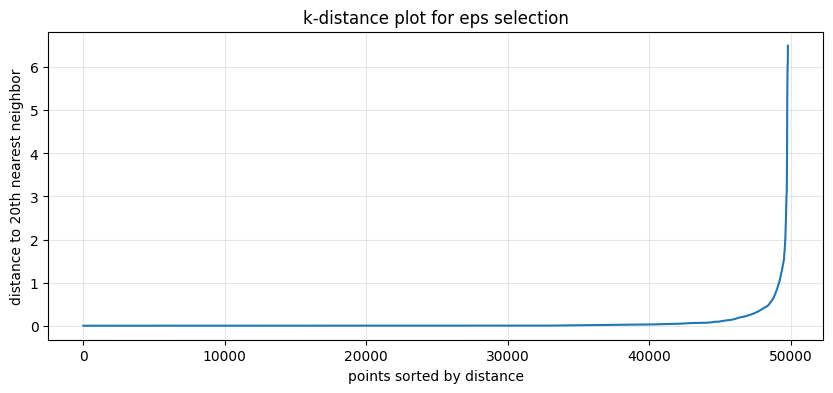

min_samples = 20
suggested eps range: 0.09 to 0.66


In [14]:
#computing k-distance for eps selection
#using min_samples=2*num_features as a rule of thumb (so 20 here)
min_samples = 2 * X_scaled.shape[1]

nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)

#sorting k-th nearest neighbor distance for each point
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 4))
plt.plot(k_distances)
plt.xlabel("points sorted by distance")
plt.ylabel(f"distance to {min_samples}th nearest neighbor")
plt.title("k-distance plot for eps selection")
plt.grid(alpha=0.3)
plt.show()

print(f"min_samples = {min_samples}")
print(f"suggested eps range: {np.percentile(k_distances, 90):.2f} to {np.percentile(k_distances, 98):.2f}")

## Reading the k-distance plot

The elbow in the plot is where the distance to the k-th nearest neighbor starts climbing sharply. The fact that this curve stays almost flat until way out past 40,000 points and then shoots up is actually meaningful. It tells me the data is extremely dense everywhere, with only a small fraction of points living in sparse regions. That's already a hint that DBSCAN is going to struggle to find distinct clusters.

I'm testing a few eps values around the elbow to see which gives the best clustering.


In [15]:
#testing a few eps values
eps_candidates = [
    np.percentile(k_distances, 85),
    np.percentile(k_distances, 90),
    np.percentile(k_distances, 95),
    np.percentile(k_distances, 98),
]

dbscan_results = []

for eps in eps_candidates:
    db = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
    labels = db.fit_predict(X_scaled)
    
    #counting clusters (excluding noise which is -1)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    
    #only compute metrics if there are actual clusters
    if n_clusters >= 2:
        #ARI uses all points including noise
        ari = adjusted_rand_score(y, labels)
        
        #silhouette only on non-noise points since noise isn't a real cluster
        non_noise_mask = labels != -1
        if non_noise_mask.sum() > 1 and len(set(labels[non_noise_mask])) > 1:
            sil = silhouette_score(
                X_scaled[non_noise_mask], 
                labels[non_noise_mask],
                sample_size=min(10000, non_noise_mask.sum()),
                random_state=42
            )
        else:
            sil = np.nan
    else:
        ari = np.nan
        sil = np.nan
    
    dbscan_results.append({
        "eps": eps,
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "noise_pct": n_noise / len(labels),
        "ari": ari,
        "silhouette": sil,
        "labels": labels
    })
    
    print(f"eps={eps:.2f} | clusters={n_clusters} | noise={n_noise} ({n_noise/len(labels)*100:.1f}%) | ARI={ari:.4f} | silhouette={sil:.4f}" if not np.isnan(ari) else f"eps={eps:.2f} | clusters={n_clusters} | noise={n_noise} (no metrics: need >=2 clusters)")

eps=0.05 | clusters=143 | noise=6651 (13.4%) | ARI=-0.1112 | silhouette=0.3738
eps=0.09 | clusters=55 | noise=4319 (8.7%) | ARI=-0.1201 | silhouette=0.3159
eps=0.28 | clusters=32 | noise=1997 (4.0%) | ARI=-0.0920 | silhouette=0.4527
eps=0.66 | clusters=27 | noise=749 (1.5%) | ARI=-0.0975 | silhouette=0.3826


In [16]:
#picking the dbscan result with highest ARI among valid ones
valid_results = [r for r in dbscan_results if not np.isnan(r["ari"])]

if valid_results:
    best_dbscan = max(valid_results, key=lambda r: r["ari"])
    best_dbscan_labels = best_dbscan["labels"]
    
    print(f"best dbscan: eps={best_dbscan['eps']:.2f}")
    print(f"clusters found: {best_dbscan['n_clusters']}")
    print(f"noise points: {best_dbscan['n_noise']} ({best_dbscan['noise_pct']*100:.1f}%)")
    print(f"ARI = {best_dbscan['ari']:.4f}")
    print(f"silhouette = {best_dbscan['silhouette']:.4f}")
else:
    print("no valid dbscan results with 2+ clusters")

best dbscan: eps=0.28
clusters found: 32
noise points: 1997 (4.0%)
ARI = -0.0920
silhouette = 0.4527


In [17]:
#dbscan cluster composition including noise as its own category
if valid_results:
    composition_db = pd.crosstab(
        pd.Series(best_dbscan_labels, name="cluster"),
        pd.Series(y, name="label"),
        normalize="index"
    ).round(3)
    
    print(f"dbscan cluster composition (-1 = noise):")
    print(composition_db)
    print(f"\ncluster sizes:")
    print(pd.Series(best_dbscan_labels).value_counts().sort_index())

dbscan cluster composition (-1 = noise):
label    Benign    Bot
cluster               
-1        1.000  0.000
 0        0.571  0.429
 1        1.000  0.000
 2        1.000  0.000
 3        1.000  0.000
 4        1.000  0.000
 5        1.000  0.000
 6        1.000  0.000
 7        1.000  0.000
 8        1.000  0.000
 9        1.000  0.000
 10       1.000  0.000
 11       1.000  0.000
 12       1.000  0.000
 13       1.000  0.000
 14       1.000  0.000
 15       1.000  0.000
 16       1.000  0.000
 17       1.000  0.000
 18       1.000  0.000
 19       1.000  0.000
 20       1.000  0.000
 21       1.000  0.000
 22       1.000  0.000
 23       1.000  0.000
 24       1.000  0.000
 25       1.000  0.000
 26       1.000  0.000
 27       1.000  0.000
 28       1.000  0.000
 29       1.000  0.000
 30       1.000  0.000
 31       1.000  0.000

cluster sizes:
-1      1997
 0     31476
 1      8821
 2      1150
 3       188
 4      1346
 5      1509
 6       117
 7       957
 8       264
 9      

## What DBSCAN actually found

DBSCAN's ARI is -0.09 across the board regardless of eps, which is worse than KMeans. But the cluster composition is striking and tells the same story as KMeans did, just more extremely.

At eps=0.28, DBSCAN found 32 clusters total. Cluster 0 is massive at 31,476 flows and mixed at 57% Benign and 43% Bot; almost every bot flow in the sample ended up here. All 31 other clusters are 100% Benign and most of them are small (20-200 points each), representing tight little sub-regions of benign traffic. The noise region of 1,997 points is 0% Bot; every single noise point is Benign.

That last point surprised me the most. I went in thinking bots would show up in the noise region since attack traffic is supposed to be anomalous. Instead it's the exact opposite; bot traffic is the densest, most uniform traffic in the dataset. It's the benign traffic that's varied and spread out.

In [18]:
#how much of the noise is actually bot traffic
if valid_results:
    noise_mask = best_dbscan_labels == -1
    if noise_mask.sum() > 0:
        noise_bot_pct = (y[noise_mask] == "Bot").mean()
        print(f"noise region: {noise_mask.sum()} points")
        print(f"percentage of noise that is Bot: {noise_bot_pct*100:.1f}%")
        print(f"baseline bot percentage in sample: {(y == 'Bot').mean()*100:.1f}%")
        
        if noise_bot_pct > (y == "Bot").mean() * 1.5:
            print("\nnoise region is significantly enriched for bot traffic")
        elif noise_bot_pct < (y == "Bot").mean() * 0.5:
            print("\nnoise region is significantly depleted of bot traffic")
        else:
            print("\nnoise region has roughly the baseline bot rate")

noise region: 1997 points
percentage of noise that is Bot: 0.0%
baseline bot percentage in sample: 27.1%

noise region is significantly depleted of bot traffic


## Why this is actually a meaningful finding

You'd think bots would be anomalies and density-based outlier detection would catch them, but this result shows that isn't true, at least for this dataset and this attack type. Bots are automated and repetitive, so they produce similar flows which makes them the least anomalous traffic in the space. Benign traffic, which comes from human behavior across many applications, ends up looking more like outliers than the bots do.

If anything, this points to a different angle for detection: flag the densest regions of feature space, not the most spread out ones. That inverts the usual anomaly detection logic but makes sense for this kind of attack.


# Visualizing the Clusters

To actually see what's going on, I'm using PCA to reduce the 10-dimensional feature space down to 2D for plotting. PCA isn't used for the clustering itself, just for visualization.

The first plot shows the true labels so you can see where bot and benign flows sit in feature space. The next two plots show what KMeans and DBSCAN came up with.

In [19]:
#pca for 2d visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"variance explained by 2 components: {pca.explained_variance_ratio_.sum()*100:.1f}%")

variance explained by 2 components: 44.4%


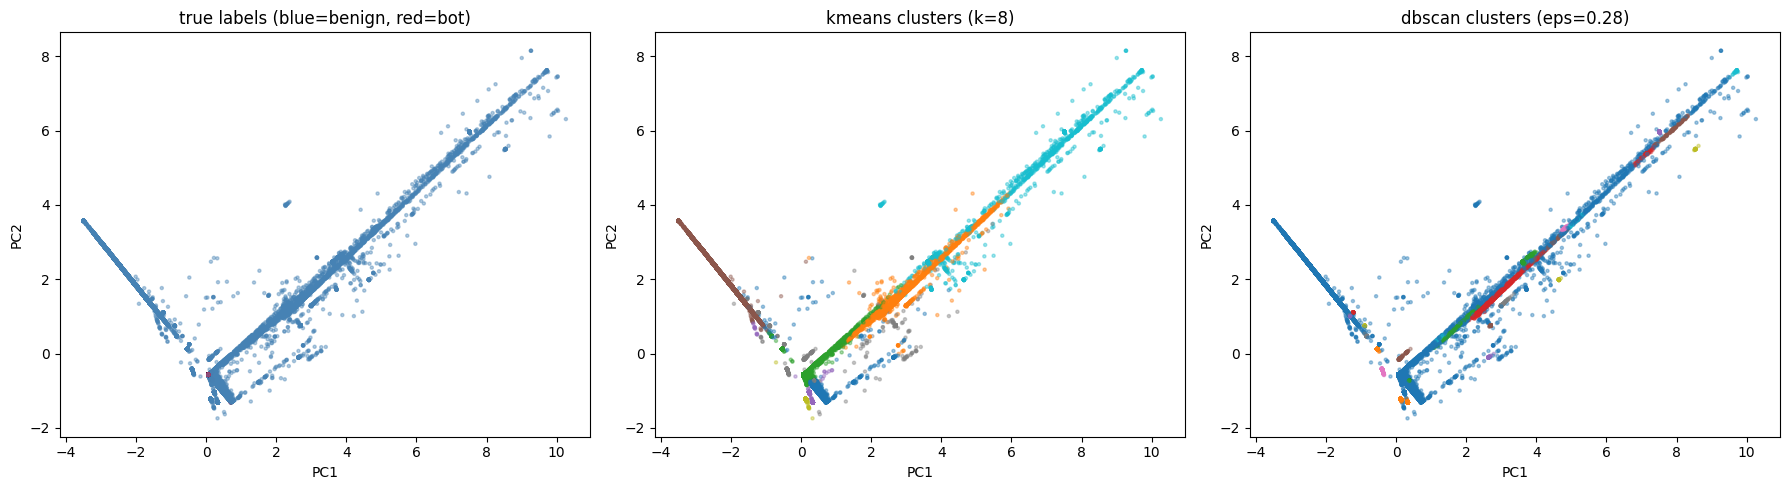

In [20]:
#plotting true labels, kmeans, and dbscan side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#true labels
colors_true = ["steelblue" if l == "Benign" else "crimson" for l in y]
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors_true, alpha=0.4, s=5)
axes[0].set_title("true labels (blue=benign, red=bot)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

#kmeans
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=best_kmeans_labels, cmap="tab10", alpha=0.4, s=5)
axes[1].set_title(f"kmeans clusters (k={best_k})")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

#dbscan
if valid_results:
    axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=best_dbscan_labels, cmap="tab10", alpha=0.4, s=5)
    axes[2].set_title(f"dbscan clusters (eps={best_dbscan['eps']:.2f})")
    axes[2].set_xlabel("PC1")
    axes[2].set_ylabel("PC2")

plt.tight_layout()
plt.show()

## What the PCA plot reveals

The visualization is where everything clicks into place. The data doesn't look like two blobs; it looks like a checkmark with a short arm and a long arm extending out from a denser origin region.

Looking at the true labels plot on the left, the bot traffic (red) isn't in its own corner. It's sitting directly on top of one of the benign arms. The two classes are co-located in this feature space; they overlap so heavily that no partition of the space could cleanly separate them. That's why the ARI is negative no matter what method or parameters I use.

The KMeans and DBSCAN plots show both methods finding the same overall shape: both arms of the checkmark plus the denser center get chopped into sub-regions. But those sub-regions are driven by position along the arms, not by class.

This is probably the most important plot in the notebook. It visually explains why clustering can't separate these classes; the classes aren't separated in feature space to begin with.

# Comparing KMeans and DBSCAN

Putting the two methods side by side to see which one did better on this problem.


In [21]:
#side by side comparison table
comparison = pd.DataFrame({
    "method": ["KMeans", "DBSCAN"],
    "best_param": [f"k={best_k}", f"eps={best_dbscan['eps']:.2f}"] if valid_results else [f"k={best_k}", "N/A"],
    "n_clusters": [best_k, best_dbscan["n_clusters"] if valid_results else "N/A"],
    "ARI": [best_kmeans["ari"], best_dbscan["ari"] if valid_results else np.nan],
    "silhouette": [best_kmeans["silhouette"], best_dbscan["silhouette"] if valid_results else np.nan],
})

print("comparison of clustering methods:")
print(comparison.to_string(index=False))

comparison of clustering methods:
method best_param  n_clusters       ARI  silhouette
KMeans        k=8           8 -0.002300    0.743049
DBSCAN   eps=0.28          32 -0.091968    0.452702


## Which method is better?

Neither method succeeded at the task the research question was asking about. Both produced ARI near or below zero, meaning neither aligned with the bot/benign split.

If I had to pick, KMeans edges out DBSCAN on this problem. KMeans got an ARI of roughly 0 (essentially random alignment) with a silhouette of 0.74 (very well-defined clusters). DBSCAN got an ARI of -0.09 (slightly worse than random) with a silhouette of 0.45 (moderately defined clusters).

But that comparison almost doesn't matter. The real takeaway from both methods is the same; they both landed on cluster structures that captured varieties of benign traffic while lumping bots into a single large dense region. Different algorithms, same underlying finding about the data's shape.

# Interpretation

## The research question, answered

**Can KMeans and DBSCAN naturally separate bot from benign traffic without using labels?**

For this dataset and feature set, no. Every ARI I measured was at or below zero, which means neither method found clusters that aligned with the bot/benign boundary any better than random assignment would have. The negative result is consistent across both algorithms and across a range of hyperparameters, so it's not a tuning problem.

## Why it didn't work

The interesting question is why that happened. A few things fit together to explain it.

Bot traffic is too homogeneous. Looking at the cluster compositions, bot flows ended up concentrated in one large mixed cluster in both KMeans and DBSCAN. This is the opposite of what you'd expect if bots were anomalous. They're actually the most repetitive, most uniform traffic in the dataset. That makes sense when you think about it; bots are automated, they follow scripts, they send requests in predictable patterns. Human-driven traffic is way more varied.

Benign traffic has rich internal structure. KMeans at k=8 found seven different 100% benign clusters and DBSCAN found 31 of them. That's the signal that was drowning out the bot/benign boundary. Benign traffic breaks down into lots of sub-types (different protocols, connection patterns, connection sizes) and those sub-types are bigger than the bot/benign distinction in feature space.

The classes also just overlap in feature space. The PCA visualization made this visible. Bots don't occupy their own region; they sit on top of one of the benign arms. No matter how you slice feature space, any boundary you draw will have bots and benigns on both sides of it.

## What this finding means

This isn't a "feature selection needs more work" result. The top features had normalized class differences of 1.0, which is as strong a signal as you can get. The result holds even with the best possible feature set by that measure. That suggests the problem isn't the features I picked; it's the geometry of the classes themselves in this type of data.

For intrusion detection, this means unsupervised clustering isn't a good primary tool for bot detection on flow-level features. The main assumption of clustering, that different classes live in different regions of feature space, doesn't hold here. Bots and benign flows live in the same neighborhoods.

## Silhouette vs ARI: why both matter

The high silhouette (0.74) combined with the near-zero ARI is the clearest summary of the whole result. It's saying two things at once: there is clean, well-defined cluster structure in this data, and that structure does not correspond to the labels I care about. Both of those statements are true at the same time. Without the silhouette metric I'd only be able to say clustering failed. With it, I can say more precisely what failed and what didn't.

## A more useful question

If clustering can't answer "is this flow a bot?", it can still answer other questions that might be useful in a real security pipeline. What kind of benign traffic is this flow most similar to? That's useful for profiling normal behavior. Is this flow in a dense region or a sparse one? That's still useful for anomaly detection, just with inverted expectations for bots. Does this flow join a group that's growing rapidly? That could be useful for detecting coordinated attacks. Clustering as a tool isn't wasted here; it's just answering a different question than the one RQ2 asked.

# Limitations

- Sample size. I used 50,000 rows out of the full ~1 million. That's enough to get meaningful results but the full dataset might reveal additional structure that's too sparse to detect in a sample. DBSCAN especially benefits from more data because it relies on density estimation.

- Single day of traffic. The Friday February 3rd file is one day of captured traffic with one type of bot attack. The finding that bots are homogeneous and benign traffic is varied is probably specific to this attack type. More sophisticated or polymorphic attacks might produce more varied flows that would cluster differently. A more thorough analysis would validate on multiple days and cross-reference against other datasets like CIC-DDoS-2019 or UNSW-NB15.

- Feature selection used labels. Even though clustering itself didn't use labels, my feature selection step did. I picked features based on which ones differed most between bot and benign classes. In a real production setting where you don't have any labels at all, you'd need a different approach; maybe using variance or statistical tests to pick informative features without reference to classes. Worth noting though: even with this advantage, clustering still didn't separate the classes. That's a strong negative result.

- Assumption mismatch. KMeans assumes spherical clusters and DBSCAN assumes clusters are dense regions separated by sparse regions. Neither assumption is guaranteed to hold for network flow data, which has complex structure driven by protocol types, user behavior patterns, and attack characteristics. A more sophisticated clustering method like Gaussian Mixture Models or HDBSCAN might fit this data better, though based on the PCA visualization where the classes are clearly overlapping, I'm not sure even a better algorithm would produce a positive result.

- Only two classes. This dataset only has Bot vs Benign, so I'm essentially doing binary separation. In reality there are many attack types and many flavors of benign traffic. A multi-class setup would tell a more complete story about whether clustering can find structure beyond just the coarse bot/benign divide.


# Conclusion

I set out to answer whether KMeans and DBSCAN can separate bot from benign network traffic without using labels. The short answer is no; every configuration of both methods produced clusters that failed to align with the bot/benign boundary, with ARI values at or below zero across the board.

But the negative result ended up being more interesting than a positive one would have been, because it pointed to something specific about the shape of the data.

The data has strong cluster structure; silhouette scores up to 0.74 confirm this. But that structure is organized around types of benign traffic, not around the class boundary. Bot traffic is dense and homogeneous, not anomalous. Every bot flow in the sample got absorbed into one large dense cluster and DBSCAN's noise region contains zero bots despite bots making up 27% of the data. The classes also just overlap in feature space. The PCA visualization made this unmistakable; bot traffic sits directly on top of one of the benign regions and no boundary can cleanly separate them.

The bigger takeaway for unsupervised intrusion detection is that the usual intuition that attacks are outliers and clustering will find them doesn't hold for automated bot traffic on flow-level features. Bots are the least anomalous traffic in the space. A system built on flagging outliers would miss them entirely and flag normal benign flows instead.

## What I'd do next

The best direction for future work would be to stop trying to make clustering separate the classes directly and instead use it as a preprocessing step in a bigger pipeline. For RQ1, I'd use KMeans cluster assignments as symbolic features and run Apriori to find which combinations of cluster membership and discretized flow features are characteristic of bot traffic; that way clustering provides the representation and pattern mining handles the discrimination. I'd also try contrast-based detection where instead of treating bots as anomalies, I flag the densest regions of feature space as candidates, which inverts the usual anomaly detection logic but actually fits what I found. Finally I'd want to validate on a different attack type to see if the "bots are dense, benign is varied" pattern generalizes or if it's specific to this bot capture.

---

**GitHub Repository:** https://github.com/austinpinedo/ids-anomaly-detection

**Honor Declaration**

1. Collaborators: I referenced my earlier homeworks and project checkpoints to get started.
2. AI Tools: I used ChatGPT for guidance on DBSCAN eps selection via k-distance plots.
3. Resources: scikit-learn documentation for KMeans, DBSCAN, and metrics.
